In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

In [2]:
# -----------------------------
# Load Monte Carlo results
# -----------------------------
csv_path = "../outputs/20250725_hazard_iter_1000/percolation_overall_results.csv"

df = pd.read_csv(csv_path)

# Basic sanity check
required_cols = [
    "fail_iter",
    "load_served_ratio",
    "voltage_violations",
    "line_overload_violations",
    "powerflow_success"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only convergent power flow runs
df_valid = df[df["powerflow_success"] == True].copy()

print(f"Total MC iterations: {len(df)}")
print(f"Convergent iterations: {len(df_valid)}")

Total MC iterations: 1000
Convergent iterations: 619


In [3]:
def compute_convergence_stats(values):
    """
    Compute running mean and 95% confidence interval.

    Parameters
    ----------
    values : 1D numpy array
        Metric values from MC simulations (only valid runs)

    Returns
    -------
    n : array
        Sample size at each step
    mean : array
        Running mean
    ci_low : array
        Lower bound of 95% CI
    ci_high : array
        Upper bound of 95% CI
    """
    values = np.asarray(values)
    n = np.arange(1, len(values) + 1)

    running_mean = np.cumsum(values) / n

    running_se = np.array([
        sem(values[:i], nan_policy="omit") if i > 1 else 0.0
        for i in n
    ])

    ci_low = running_mean - 1.96 * running_se
    ci_high = running_mean + 1.96 * running_se

    return n, running_mean, ci_low, ci_high

In [4]:
metrics = {
    "load_served_ratio": "Served load ratio",
    "voltage_violations": "Voltage violations",
    "line_overload_violations": "Line overload violations"
}

results = {}

for col, label in metrics.items():
    vals = df_valid[col].values
    results[col] = compute_convergence_stats(vals)

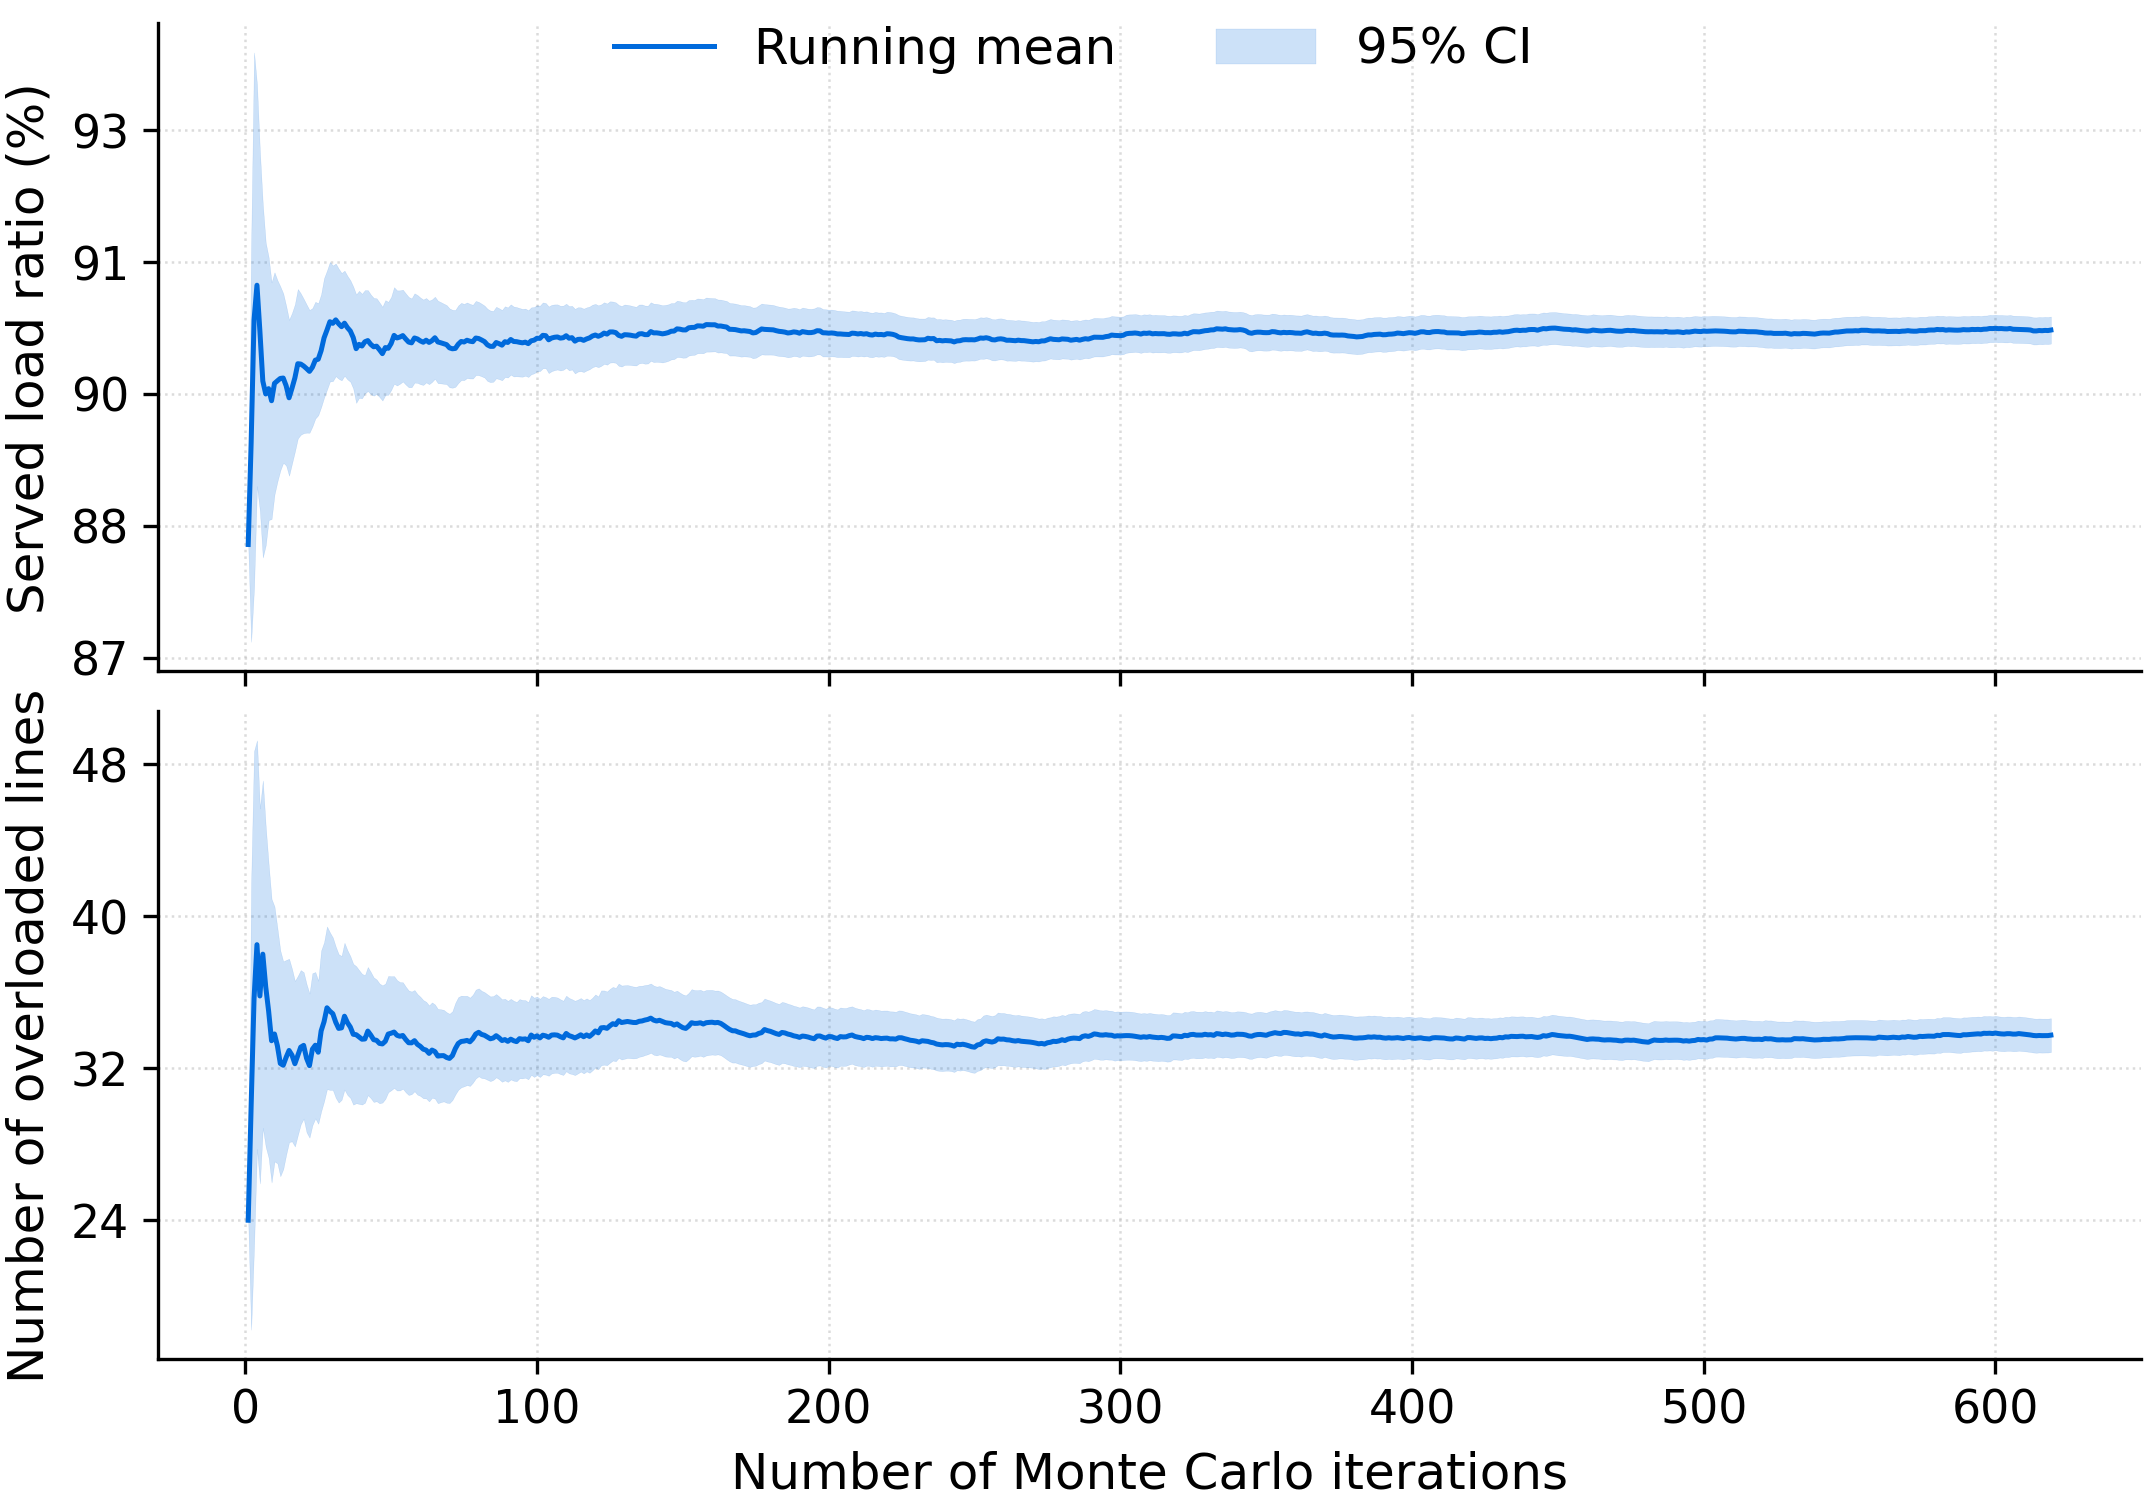

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

# -------------------------
# Publication-style settings
# -------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 0.8,
    "figure.dpi": 300,  # notebook preview
    "savefig.dpi": 800, # export
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(7.2, 5.0),   # slightly wider; good for 1-column or 1.5-column
    sharex=True,
    constrained_layout=True
)

metrics_order = [
    ("load_served_ratio", "Served load ratio (%)"),
    ("line_overload_violations", "Number of overloaded lines"),
]

line_color = "#006ADC"
ci_color = "#006ADC"  # #34D1BF

for ax, (col, label) in zip(axes, metrics_order):
    n, mean, ci_low, ci_high = results[col]

    # --- Convert served load ratio to percentage ---
    if col == "load_served_ratio":
        mean = mean * 100
        ci_low = ci_low * 100
        ci_high = ci_high * 100

        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))

    ax.plot(
        n, mean,
        lw=1.2,
        color=line_color,
        label="Running mean",
        zorder=3
    )
    ax.fill_between(
        n, ci_low, ci_high,
        color=ci_color,
        alpha=0.2,
        linewidth=0.1,
        label="95% CI",
        zorder=2
    )

    ax.set_ylabel(label)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Only bottom subplot shows x label
axes[-1].set_xlabel("Number of Monte Carlo iterations")

# Put a single legend above the top subplot (outside the plot area)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

# Optional: add a concise title (comment out if journal style dislikes titles on figures)
# axes[0].set_title("Monte Carlo convergence diagnostics")

plt.savefig("../figures/Fig_S15_mc_convergence_check.png", dpi=800, bbox_inches="tight")
plt.savefig("../figures/Fig_S15_mc_convergence_check.svg", bbox_inches="tight")